<a href="https://colab.research.google.com/github/AngellyC07/Ciencia_de_datos/blob/main/Pima_Indians.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Agenda
1. Importar librerías
2. Carga del datatset
3. Análisis de las características
3. Revisión de las 5 primeras filas
4. Revisión general de los datos
4. Detección de nulos y ceros inválidos
5. Estadística descriptiva
6. Análisis de distribuciones
7. Detección de outliers
8. Probabilidad global de diabetes
9. Comparación entre grupos
10. Correlaciones y relevancia de variables
11. Perfil observado de mayor riesgo

###Importar Librerías

In [2]:
# ==========================================
# BLOQUE 1. IMPORTAR LIBRERÍAS
# ==========================================

# pandas se usa para manejar tablas de datos
import pandas as pd

# numpy se usa para operaciones numéricas
import numpy as np

# matplotlib se usa para gráficas básicas
import matplotlib.pyplot as plt

# seaborn se usa para gráficas estadísticas más claras
import seaborn as sns

# scipy.stats permite hacer pruebas estadísticas
from scipy import stats

###Carga del dataset

In [3]:
# ==========================================
# BLOQUE 2. CARGAR EL DATASET
# ==========================================
# configuración visual general de las gráficas
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# cargar el dataset
df = pd.read_csv("diabetes.csv")

###Revisión de las 5 primeras filas

In [4]:
# mostrar primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


###Identificación de las variables del dataset

In [5]:
# mostrar nombres de columnas
print("\nColumnas del dataset:")
print(df.columns.tolist())


Columnas del dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


###Descripción de las variales

In [45]:
# ==========================================
# DESCRIPCIÓN BÁSICA DE LAS VARIABLES
# ==========================================

import pandas as pd
from IPython.display import display

# Cargar dataset
df = pd.read_csv("diabetes.csv")

# Tabla descriptiva base
descripcion_variables = pd.DataFrame({
    "Variable": [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome"
    ],

    "Descripción": [
        "Número de embarazos que ha tenido la persona.",
        "Concentración de glucosa en sangre.",
        "Presión arterial diastólica.",
        "Grosor del pliegue cutáneo.",
        "Nivel de insulina en sangre.",
        "Índice de masa corporal.",
        "Índice asociado a antecedentes familiares de diabetes.",
        "Edad de la persona.",
        "Indica si la persona tiene diabetes o no."
    ],

    "Tipo": [
        "Cuantitativa discreta",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa discreta",
        "Cualitativa dicotómica/binaria"
    ]
})

# Agregar datos extraídos directamente del dataset
descripcion_variables["Dato"] = df.dtypes.astype(str).values
descripcion_variables["Registros"] = df.shape[0]
descripcion_variables["No nulos"] = df.notnull().sum().values
descripcion_variables["Nulos"] = df.isnull().sum().values
descripcion_variables["Ceros"] = (df == 0).sum().values
descripcion_variables["% ceros"] = ((df == 0).sum() / len(df) * 100).round(2).values
descripcion_variables["Únicos"] = df.nunique().values

# Reordenar columnas
descripcion_variables = descripcion_variables[
    ["Variable", "Descripción", "Tipo", "Dato", "Registros", "No nulos", "Nulos", "Ceros", "% ceros", "Únicos"]
]

# Mostrar tabla
display(
    descripcion_variables.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_properties(subset=["Variable"], **{
        "font-weight": "bold"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]}
    ])
)

Variable,Descripción,Tipo,Dato,Registros,No nulos,Nulos,Ceros,% ceros,Únicos
Pregnancies,Número de embarazos que ha tenido la persona.,Cuantitativa discreta,int64,768,768,0,111,14.450000,17
Glucose,Concentración de glucosa en sangre.,Cuantitativa continua,int64,768,768,0,5,0.650000,136
BloodPressure,Presión arterial diastólica.,Cuantitativa continua,int64,768,768,0,35,4.560000,47
SkinThickness,Grosor del pliegue cutáneo.,Cuantitativa continua,int64,768,768,0,227,29.560000,51
Insulin,Nivel de insulina en sangre.,Cuantitativa continua,int64,768,768,0,374,48.700000,186
BMI,Índice de masa corporal.,Cuantitativa continua,float64,768,768,0,11,1.430000,248
DiabetesPedigreeFunction,Índice asociado a antecedentes familiares de diabetes.,Cuantitativa continua,float64,768,768,0,0,0.000000,517
Age,Edad de la persona.,Cuantitativa discreta,int64,768,768,0,0,0.000000,52
Outcome,Indica si la persona tiene diabetes o no.,Cualitativa dicotómica/binaria,int64,768,768,0,500,65.100000,2


###Revisión general de los datos del dataset

In [6]:
# información general: tipos de datos y cantidad de registros no nulos
print("Información general:")
print(df.info())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


###Detección de nulos

In [7]:
# contar nulos reales
print("\nValores nulos reales por columna:")
print(df.isnull().sum())


Valores nulos reales por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


###Estadística descriptiva

Se genera un resumen estadístico general de las variables numéricas del dataset, incluyendo media, mediana, desviación estándar, valores mínimos y cuartiles.

El código .T es para que esas variables salgan como filas y no como columnas

In [8]:
# estadísticas descriptivas básicas
print("\nResumen estadístico general:")
print(df.describe().T)


Resumen estadístico general:
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.240885   11.760232  21.000  24.00000   
Outcome                   768.0    0.348958    0.476951   0.000   0.00000   

                               50%        75%     max  
Pregnancies                 3.0000    6.00000   17.00  
Glucose                   117.0000  140.25000  199.00  
BloodPressure              72.0

Todas las variables tiene 768 registros, las variables como Insulin y DiabetesPedigreeFunction presentan difencias marcadas lo que puede que sea una asimetría y posible presencia de valores extremos.

En outcome se indica que aproximadamente el 34,9% de la muestra presenta diabetes.

##Frecuencia absoluta de la variable objetivo (diabetes)

Hacemos un conteo de cuántos registros hay en cada categoría de la variable outcome que representa si tiene o no diabetes.

0 = no tiene
1 = tiene

In [9]:
# distribución de la variable objetivo
print("\nConteo de Outcome:")
print(df["Outcome"].value_counts())


Conteo de Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


El resultado muestra que 500 personas no tienen diabetes y 268 personas sí, esto permite conocer la frecuencia absoluta de cada grupo.

###Distribución porcentual de la variable objetivo (diabetes)

Qué proporción del total representa cada categoría. Por lo que, aproxiamdamente el 65,1% de la muestra son personas sin dabetes y el 34,9% son personas con diabetes.
Con normalize hacemos que el código no salga como cantidad sino como proporción, o sea en vez de 500 sale 0.65.

In [10]:
# distribución porcentual de la variable objetivo
print("\nPorcentaje de Outcome:")
print(df["Outcome"].value_counts(normalize=True) * 100)


Porcentaje de Outcome:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


###Detección de Ceros que no son naturales

Revisamos cuántos valores iguales a 0 aparecen en variables donde no tiene sentido o es muy poco probable.


In [11]:
# ==========================================
# BLOQUE 3. DETECTAR CEROS IMPOSIBLES
# ==========================================

# estas variables no deberían tomar cero desde un punto de vista clínico
# o un cero suele ser un valor faltante disfrazado
columnas_cero_invalido = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Cantidad de ceros por variable sospechosa:")
for col in columnas_cero_invalido:
    cantidad = (df[col] == 0).sum()
    porcentaje = (df[col] == 0).mean() * 100
    print(f"{col}: {cantidad} ceros ({porcentaje:.2f}%)")

Cantidad de ceros por variable sospechosa:
Glucose: 5 ceros (0.65%)
BloodPressure: 35 ceros (4.56%)
SkinThickness: 227 ceros (29.56%)
Insulin: 374 ceros (48.70%)
BMI: 11 ceros (1.43%)


Esto indica aproximadamente la cantidad de ceros que hay en cada variable que puede estar afectando el análisis.

###Conversión de Ceros a NaN

Este código crea una copia del dataset original y reemplaza por NaN los valores iguales a 0 en variables donde ese valor no es clínicamente válido, como Glucose, BloodPressure, SkinThickness, Insulin y BMI. Su propósito es corregir los datos para que esos ceros no se interpreten como mediciones reales, sino como valores faltantes.

In [12]:
# ==========================================
# BLOQUE 4. CONVERTIR CEROS INVÁLIDOS A NaN
# ==========================================

# hacer una copia del dataset original para no modificarlo directamente
df_clean = df.copy()

# reemplazar ceros inválidos por NaN
for col in columnas_cero_invalido:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# verificar cuántos faltantes quedaron
print("Valores faltantes después de convertir ceros inválidos en NaN:")
print(df_clean.isnull().sum())

Valores faltantes después de convertir ceros inválidos en NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


El resultado muestra cuántos faltantes quedaron después de esa corrección; por ejemplo, Insulin queda con 374 valores faltantes, SkinThickness con 227, BloodPressure con 35, BMI con 11 y Glucose con 5.

Esto significa que el dataset sí tenía información ausente, aunque inicialmente no apareciera como nulo.

###Medidas descriptivas detalladas

Resumen estadístico detallado de todas las variables predictoras del dataset ya corregido (df_clean), excluyendo Outcome. Para cada variable calcula cuántos valores válidos tiene (count_validos), cuántos faltan (missing y missing_%), su media, mediana, desviación estándar, varianza, mínimo, máximo, cuartiles (q1 y q3), además de asimetría (skew) y curtosis (kurtosis).

In [13]:
# ==========================================
# BLOQUE 5. MEDIDAS DESCRIPTIVAS DETALLADAS
# ==========================================

# lista de variables predictoras
variables = [col for col in df_clean.columns if col != "Outcome"]

# crear resumen estadístico enriquecido
resumen = pd.DataFrame({
    "count_validos": df_clean[variables].count(),
    "missing": df_clean[variables].isnull().sum(),
    "missing_%": df_clean[variables].isnull().mean() * 100,
    "mean": df_clean[variables].mean(),
    "median": df_clean[variables].median(),
    "std": df_clean[variables].std(),
    "var": df_clean[variables].var(),
    "min": df_clean[variables].min(),
    "q1": df_clean[variables].quantile(0.25),
    "q3": df_clean[variables].quantile(0.75),
    "max": df_clean[variables].max(),
    "skew": df_clean[variables].skew(),
    "kurtosis": df_clean[variables].kurtosis()
})

print("Resumen estadístico detallado:")
print(resumen.sort_index())

Resumen estadístico detallado:
                          count_validos  missing  missing_%        mean  \
Age                                 768        0   0.000000   33.240885   
BMI                                 757       11   1.432292   32.457464   
BloodPressure                       733       35   4.557292   72.405184   
DiabetesPedigreeFunction            768        0   0.000000    0.471876   
Glucose                             763        5   0.651042  121.686763   
Insulin                             394      374  48.697917  155.548223   
Pregnancies                         768        0   0.000000    3.845052   
SkinThickness                       541      227  29.557292   29.153420   

                            median         std           var     min  \
Age                        29.0000   11.760232    138.303046  21.000   
BMI                        32.3000    6.924988     47.955463  18.200   
BloodPressure              72.0000   12.382158    153.317842  24.000   
Diabe

SkinThickness e Insulin muestran muchos faltantes, lo que confirma que tenían varios ceros inválidos convertidos a NaN; variables como Glucose, BMI y Age tienen medias y medianas relativamente cercanas, mientras que Insulin y DiabetesPedigreeFunction muestran mayor diferencia entre media, mediana y máximo, lo que sugiere asimetría positiva y presencia de valores extremos.

Skew y kurtosis permiten evaluar la forma de la distribución: valores altos de asimetría indican cola hacia la derecha, y curtosis elevada sugiere mayor presencia de extremos.

###Distribución de cada variable

Se recorre cada variable numérica del dataset y genera para cada una un histograma con curva de densidad para analizar cómo se distribuyen los datos, es decir, si una variable está concentrada en ciertos valores, si es simétrica o asimétrica, si tiene colas largas o si presenta posibles valores extremos.

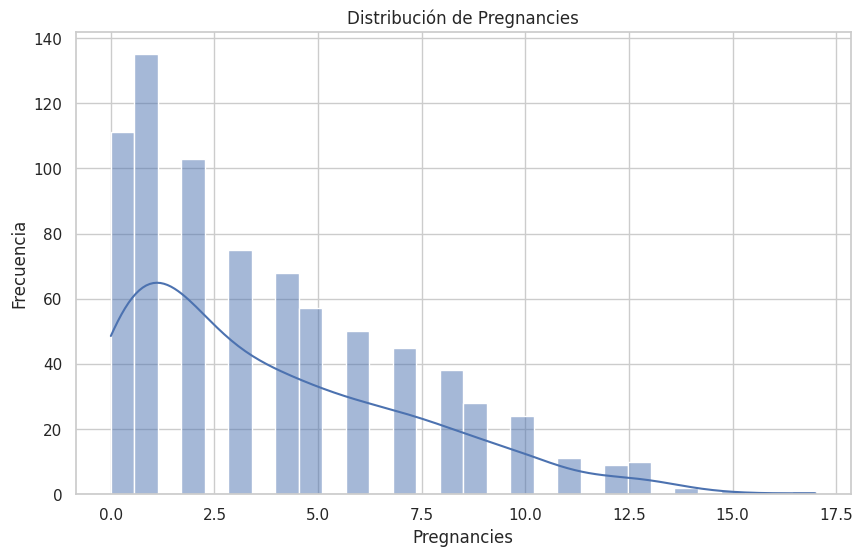

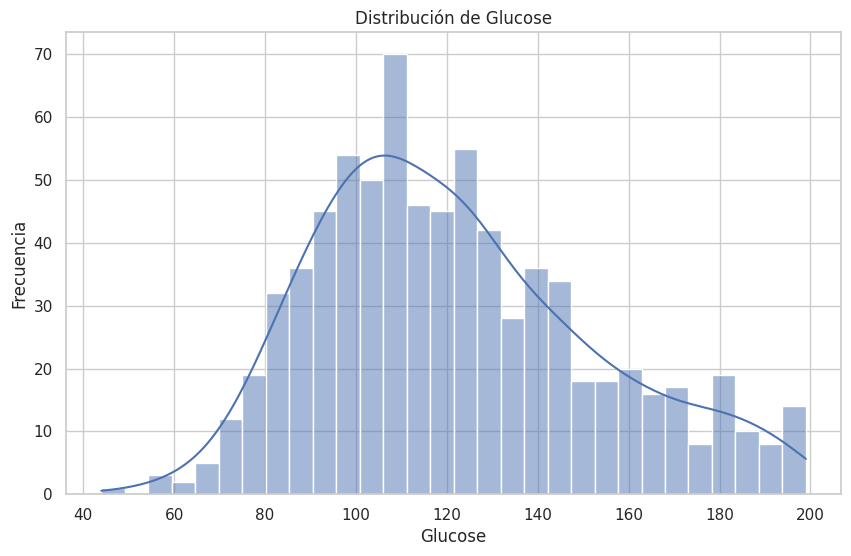

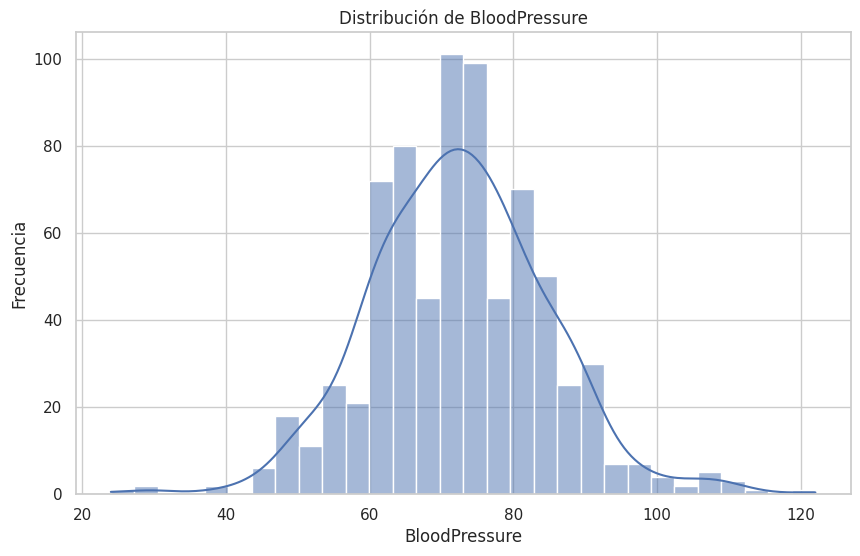

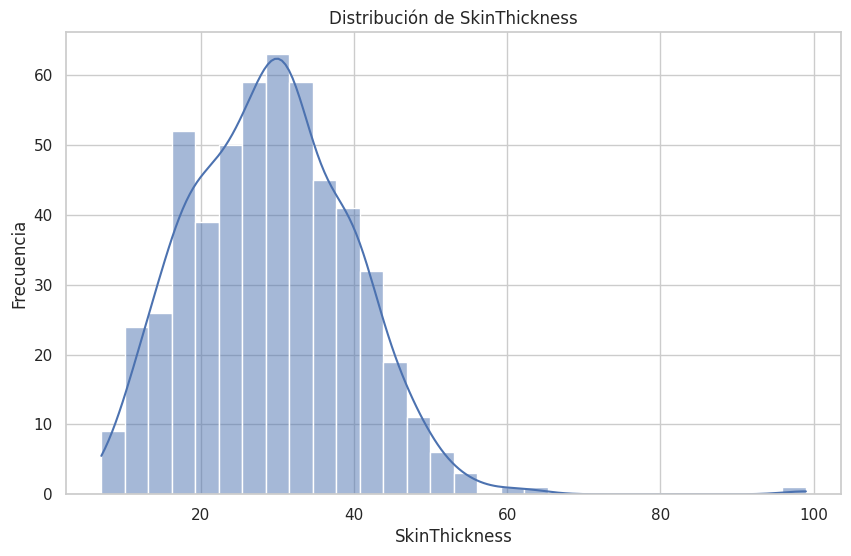

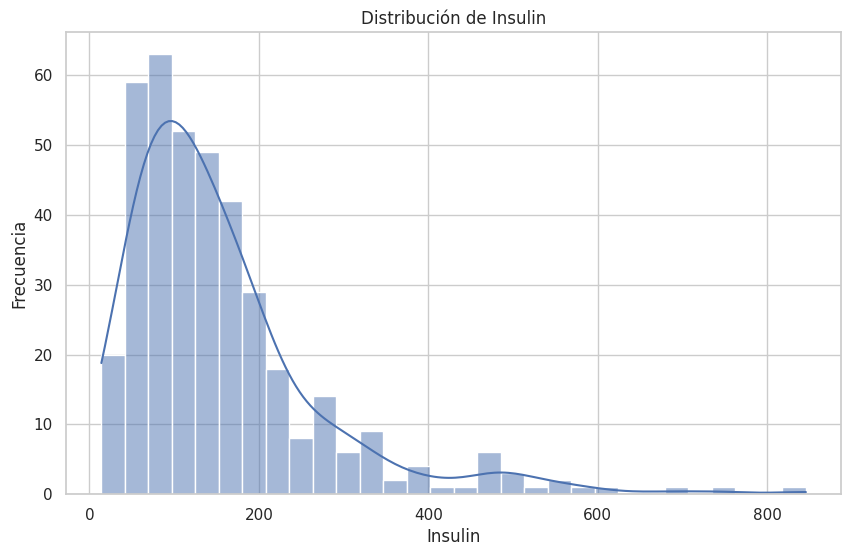

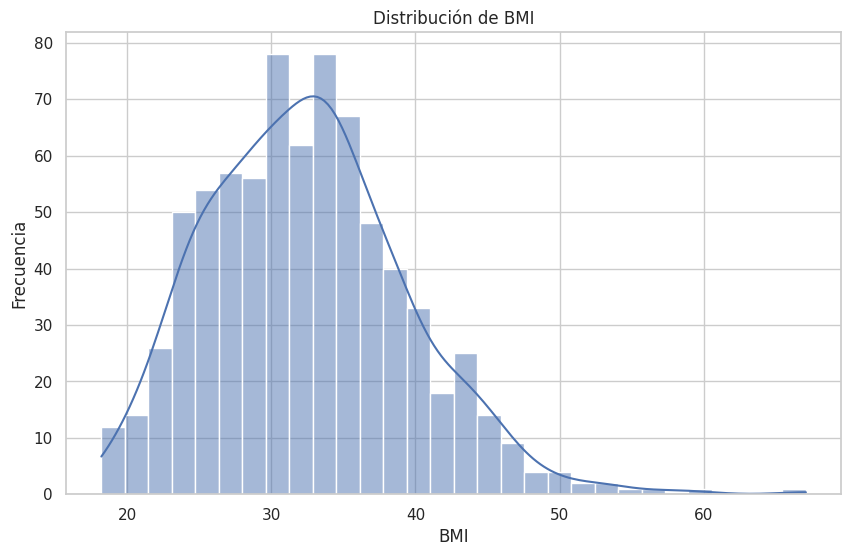

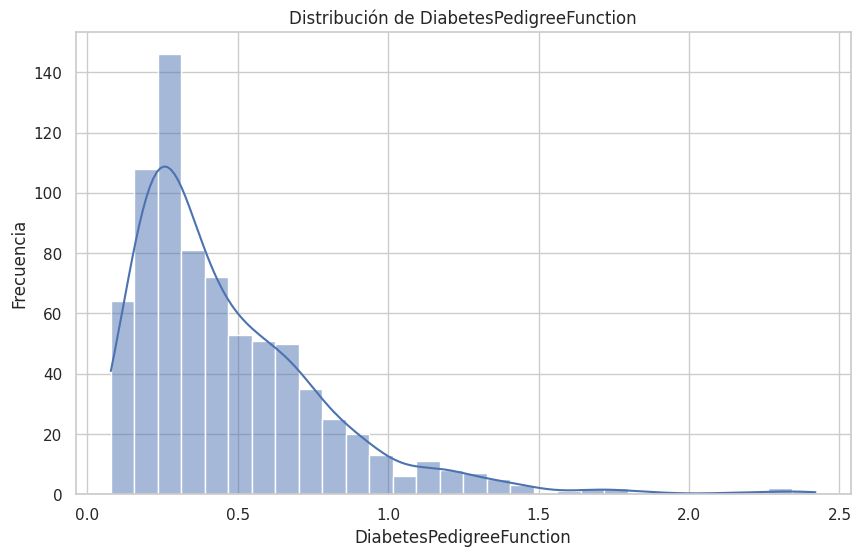

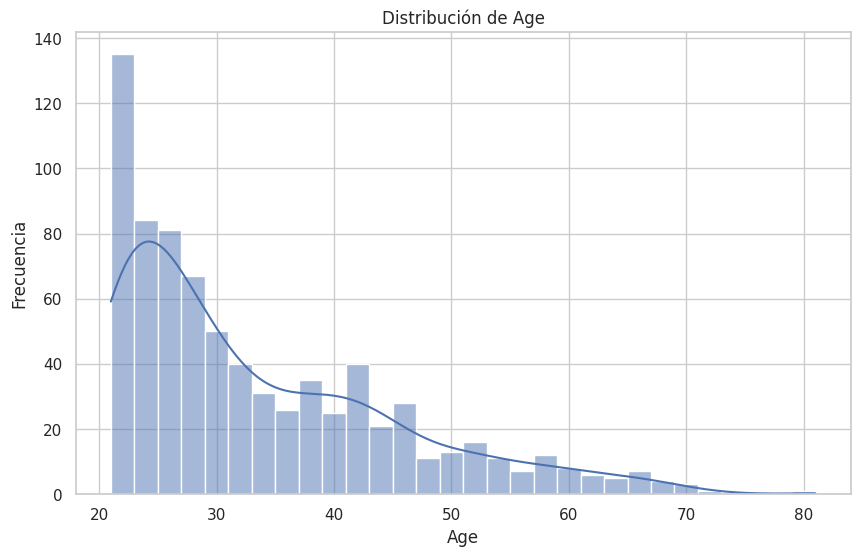

In [14]:
# ==========================================
# BLOQUE 6. HISTOGRAMAS Y DENSIDADES
# ==========================================

for col in variables:
    plt.figure()

    # histograma con curva de densidad
    sns.histplot(df_clean[col].dropna(), bins=30, kde=True)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Se observa que Pregnancies, Insulin, DiabetesPedigreeFunction y Age presentan una asimetría positiva, porque la mayoría de los valores se concentra en rangos bajos o medios y la cola se extiende hacia la derecha. En cambio, variables como Glucose, BloodPressure y BMI se ven más centradas, aunque no perfectamente simétricas.

Pregnancies: la mayoría de personas tiene pocos embarazos y hay menos casos a medida que el número de embarazos aumenta.

Glucose: la glucosa se concentra principalmente en valores intermedios, aunque hay una cola hacia valores altos.

BloodPressure: la presión arterial se agrupa sobre todo alrededor de valores medios y muestra una distribución relativamente concentrada.

SkinThickness: el grosor cutáneo se concentra en valores medios-bajos y presenta algunos valores altos poco frecuentes.

Insulin: la insulina está muy concentrada en valores bajos o moderados, pero tiene varios valores altos extremos.

BMI: el IMC se distribuye principalmente en valores medios, con una ligera cola hacia valores altos.

DiabetesPedigreeFunction: esta variable se concentra en valores bajos y presenta una cola larga hacia la derecha, indicando algunos casos altos aislados.

Age: la mayoría de personas está en edades bajas o medias, y hay menos casos en edades altas.

###Detección de valores atípicos (outliers) mediante boxplots

Se recorre cada variable numérica del dataset y genera un boxplot para cada una. El boxplot sirve para ver de forma rápida: el valor central de la variable, qué tanto se dispersan los datos, dónde está la mayor concentración, y si existen valores atípicos (outliers).



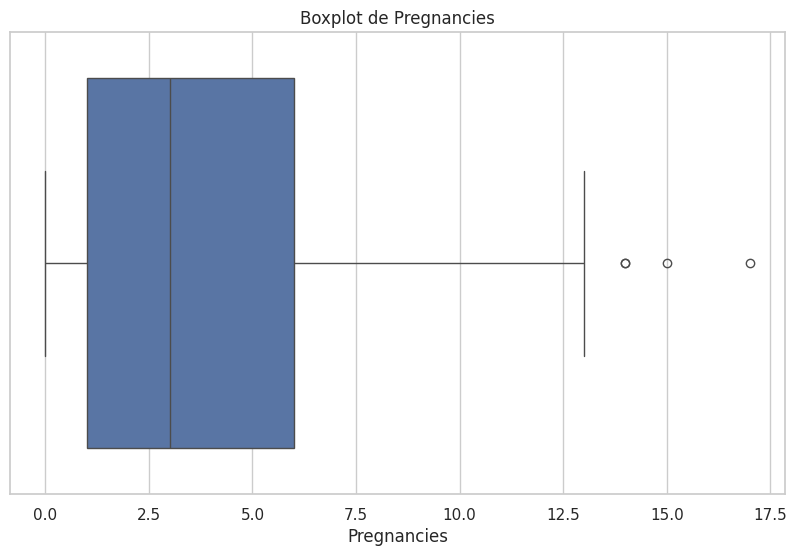

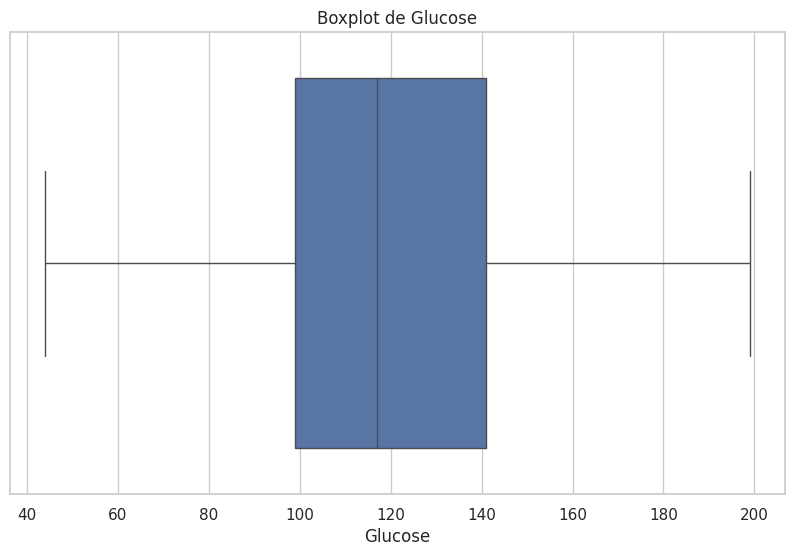

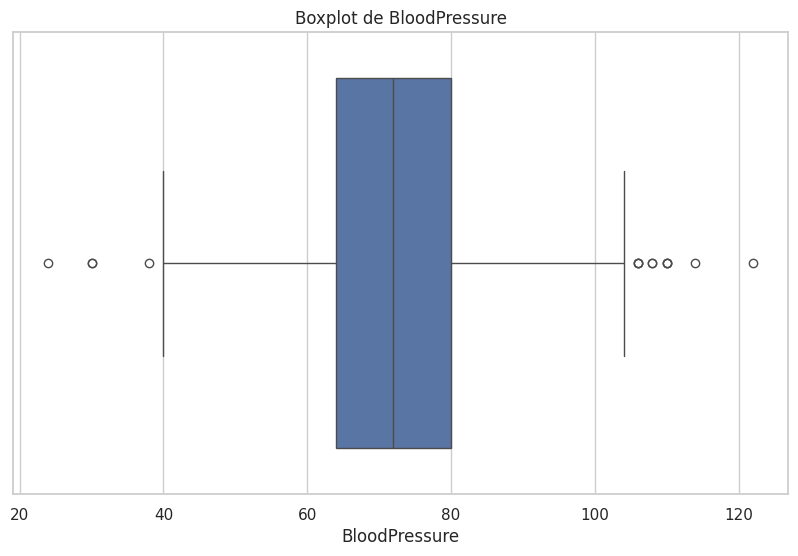

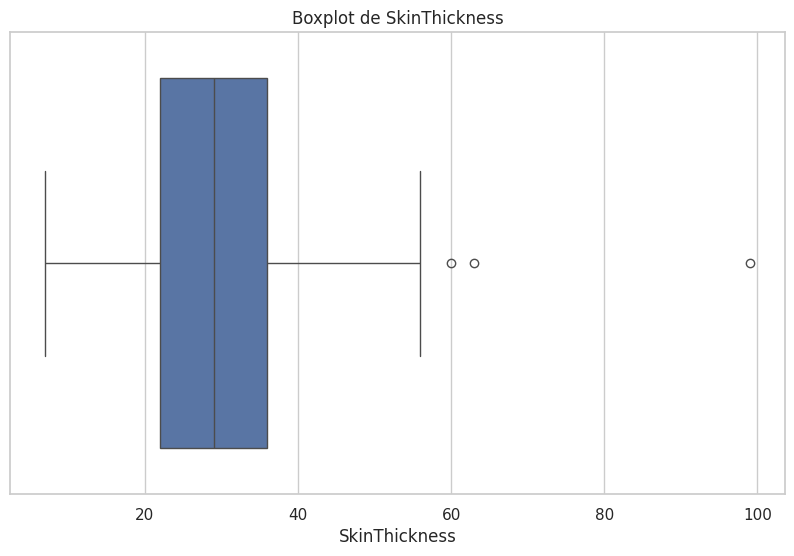

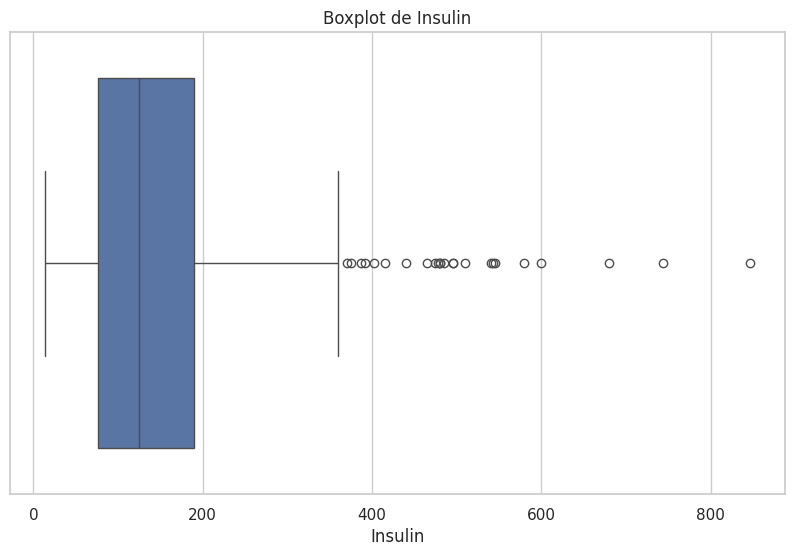

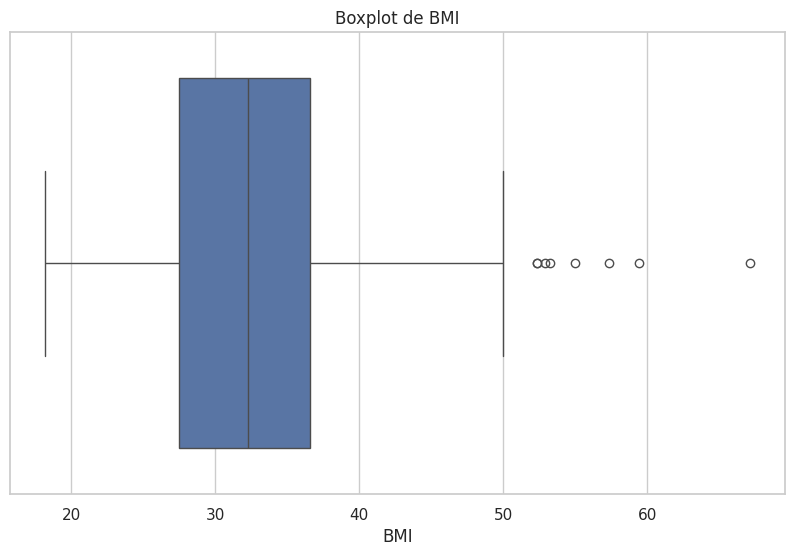

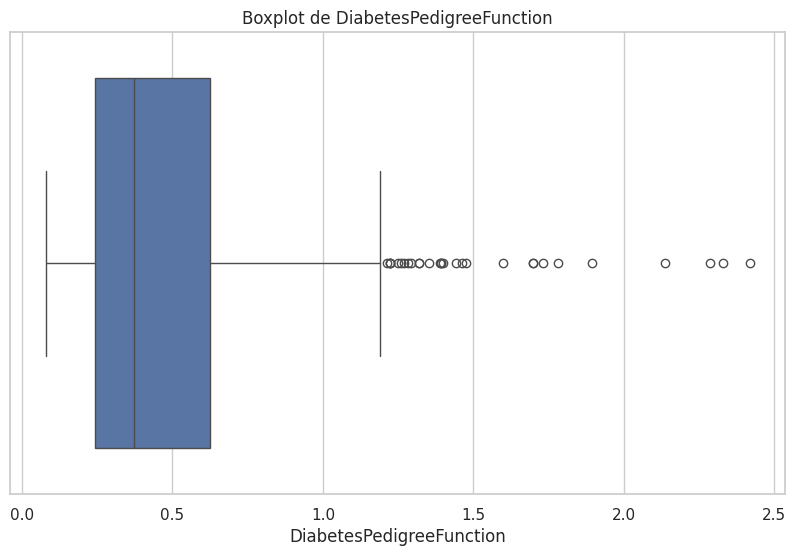

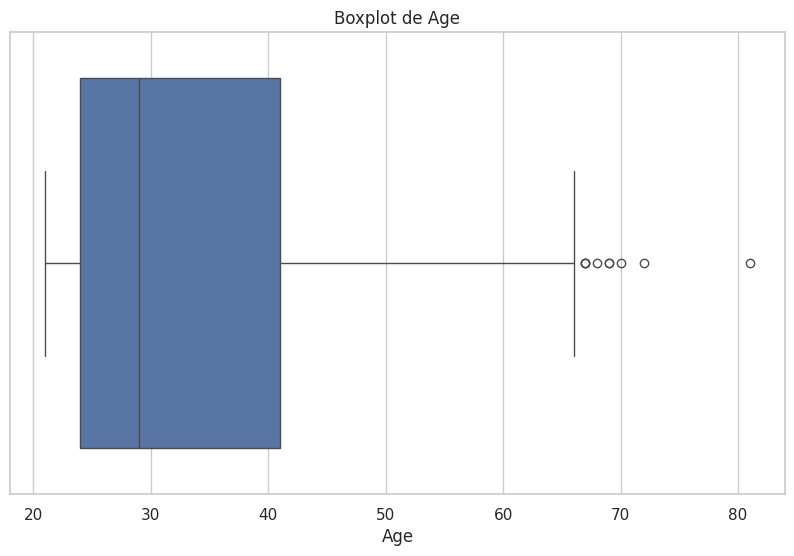

In [15]:
# ==========================================
# BLOQUE 7. BOXPLOTS Y OUTLIERS
# ==========================================

for col in variables:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

Pregnancies: a mediana está cerca de 3 embarazos, la mayor parte de los datos se concentra entre 1 y 6, y aparecen outliers altos alrededor de 14, 15 y 17.

Glucose: la mediana está cerca de 117, el 50% central de los datos está aproximadamente entre 99 y 141, la mayoría de las personas tiene niveles de glucosa en un rango intermedio de 99 a 141, y no se ven casos extremadamente separados del resto.

BloodPressure: la mayoría de las personas tiene presión arterial diastólica en valores moderados, entre 64 y 80, aunque hay unas pocas con valores anormalmente bajos o altos.

SkinThickness: la mayoría de las personas tiene grosor cutáneo en un rango medio, entre 22 y 36, pero unas pocas tienen valores mucho más altos.

Insulin: La mayoría de las personas tiene niveles de insulina entre 76 y 190, pero hay pocas personas con valores extremadamente altos, lo que muestra mucha variabilidad en esta medida.

BMI: la mayoría de las personas tiene un IMC entre 27 y 36.6, es decir, en rangos medios a altos, y unas pocas tienen valores mucho más elevados.

DiabetesPedigreeFunction: la mayoría de las personas tiene valores bajos o moderados de predisposición familiar a diabetes, entre 0.24 y 0.63, pero hay unas pocas con antecedentes familiares mucho más marcados.

Age: la mayor parte de las edades del dataset está concentrada en un rango aproximado entre 24 y 41 años, por personas relativamente jóvenes.

La mediana se ubica cerca de los 29 años. Los bigotes se extienden hasta edades cercanas a los 65 años, y por encima de ese valor aparecen varios outliers, aproximadamente entre 67 y 81 años, lo que indica que sí hay personas de mayor edad, pero son pocos casos comparados con el resto de la muestra.

###Detección de valores atípicos con el método IQR

Hacemos una detección formal de valores atípicos (outliers) para cada variable usando el criterio del rango intercuartílico (IQR).

Primero toma cada variable por separado, elimina los valores faltantes, calcula el primer cuartil (Q1), el tercer cuartil (Q3) y el IQR, que es la distancia entre ambos.

Luego define un límite inferior y un límite superior para decidir qué valores quedan demasiado lejos del comportamiento central.

Q1: valor por debajo del cual está el 25% de los datos.
Q3: valor por debajo del cual está el 75% de los datos.
IQR: rango central del 50% de los datos, resta de Q3 - Q1.

In [16]:
# ==========================================
# BLOQUE 8. DETECCIÓN FORMAL DE OUTLIERS (IQR)
# ==========================================

# crear lista para guardar resultados
tabla_outliers = []

for col in variables:
    # eliminar NaN para calcular percentiles bien
    serie = df_clean[col].dropna()

    # calcular cuartiles
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    # calcular rango intercuartílico
    iqr = q3 - q1

    # definir límites de outliers
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # contar outliers
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    pct_outliers = n_outliers / len(serie) * 100

    tabla_outliers.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Limite_inferior": lim_inf,
        "Limite_superior": lim_sup,
        "Cantidad_outliers": n_outliers,
        "Porcentaje_outliers": pct_outliers
    })

tabla_outliers = pd.DataFrame(tabla_outliers).sort_values("Porcentaje_outliers", ascending=False)

print("Tabla de outliers por criterio IQR:")
print(tabla_outliers)

Tabla de outliers por criterio IQR:
                   Variable        Q1         Q3       IQR  Limite_inferior  \
4                   Insulin  76.25000  190.00000  113.7500          -94.375   
6  DiabetesPedigreeFunction   0.24375    0.62625    0.3825           -0.330   
2             BloodPressure  64.00000   80.00000   16.0000           40.000   
7                       Age  24.00000   41.00000   17.0000           -1.500   
5                       BMI  27.50000   36.60000    9.1000           13.850   
3             SkinThickness  22.00000   36.00000   14.0000            1.000   
0               Pregnancies   1.00000    6.00000    5.0000           -6.500   
1                   Glucose  99.00000  141.00000   42.0000           36.000   

   Limite_superior  Cantidad_outliers  Porcentaje_outliers  
4          360.625                 24             6.091371  
6            1.200                 29             3.776042  
2          104.000                 14             1.909959  
7       

La variable con más outliers es Insulin, con 24 valores atípicos y aproximadamente 6.09%, lo que indica que es la variable con mayor presencia de extremos altos y mayor dispersión.

Se muestra qué variables tienen más personas con valores muy alejados de lo habitual y cuáles son más estables en comparación con el resto.

###Conteo de probabiliad de cantidad de personas con y sin diabetes

Calcula frecuencia absoluta de la variable Outcome, es decir, cuenta cuántas personas hay en cada una de sus categorías después de trabajar con df_clean. En este dataset, Outcome representa la presencia o ausencia de diabetes, por lo que 0 significa no diabetes y 1 significa diabetes. La instrucción value_counts().sort_index() cuenta cuántas veces aparece cada valor y luego los ordena de menor a mayor para que primero salga el grupo 0 y después el grupo 1.

In [17]:
# ==========================================
# BLOQUE 9. PROBABILIDAD EMPÍRICA GLOBAL
# ==========================================

# calcular frecuencia absoluta
conteo_outcome = df_clean["Outcome"].value_counts().sort_index()

# calcular probabilidad empírica
prob_outcome = df_clean["Outcome"].value_counts(normalize=True).sort_index()

print("Conteos de Outcome:")
print(conteo_outcome)

Conteos de Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


###Probabilidad general de diabetes en la muestra

In [18]:
# calcular probabilidad empírica
prob_outcome = df_clean["Outcome"].value_counts(normalize=True).sort_index()

print("\nProbabilidades empíricas de Outcome:")
print(prob_outcome)


Probabilidades empíricas de Outcome:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


###Gráfico de la frecuencia de diabetes

Gráfica para mostrar la frecuencia de la variable Outcome, es decir, cuántas personas del dataset no tienen diabetes (Outcome = 0) y cuántas sí tienen diabetes (Outcome = 1).

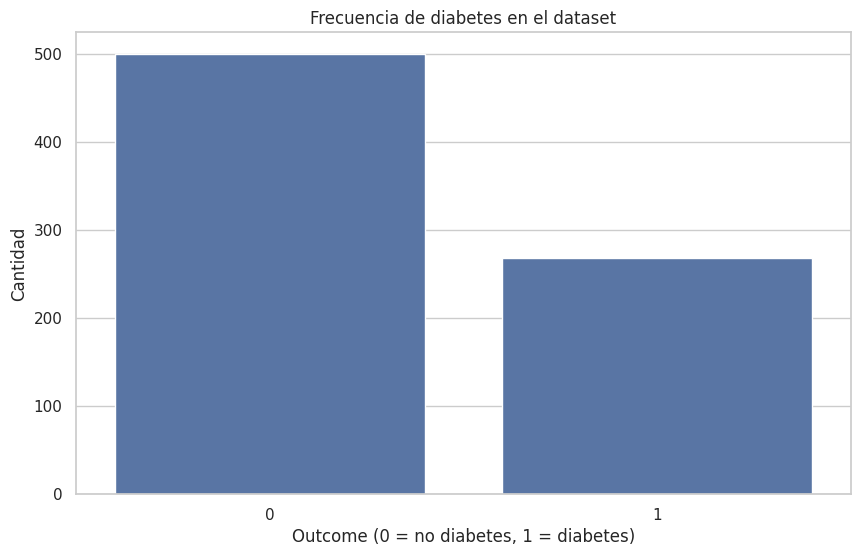

In [19]:
# gráfico de barras
plt.figure()
sns.countplot(data=df_clean, x="Outcome")
plt.title("Frecuencia de diabetes en el dataset")
plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
plt.ylabel("Cantidad")
plt.show()

###Comparación de variables entre personas con y sin diabetes

Se agrupa el dataset según la variable Outcome y calcula, para cada grupo, estadísticas descriptivas de todas las variables: cantidad de datos válidos (count), media (mean), mediana (median) y desviación estándar (std) con el objetivo de comparar cómo se comportan variables como Pregnancies, Glucose, BloodPressure, BMI, DiabetesPedigreeFunction y Age entre las personas sin diabetes (Outcome = 0) y las personas con diabetes (Outcome = 1).

In [20]:
# ==========================================
# BLOQUE 10. COMPARACIÓN POR GRUPOS
# ==========================================

# agrupar por Outcome y calcular estadísticas clave
comparacion = df_clean.groupby("Outcome")[variables].agg(["count", "mean", "median", "std"])

print("Comparación descriptiva entre personas con y sin diabetes:")
print(comparacion)

Comparación descriptiva entre personas con y sin diabetes:
        Pregnancies                            Glucose                     \
              count      mean median       std   count        mean median   
Outcome                                                                     
0               500  3.298000    2.0  3.017185     497  110.643863  107.0   
1               268  4.865672    4.0  3.741239     266  142.319549  140.0   

                   BloodPressure             ...    BMI            \
               std         count       mean  ... median       std   
Outcome                                      ...                    
0        24.776906           481  70.877339  ...   30.1  6.560737   
1        29.599199           252  75.321429  ...   34.3  6.614982   

        DiabetesPedigreeFunction                              Age             \
                           count      mean median       std count       mean   
Outcome                                          

Las personas con diabetes tienen valores típicos más altos en Pregnancies (mediana de 4 frente a 2), Glucose (140 frente a 107), BMI (34.3 frente a 30.1), DiabetesPedigreeFunction (0.449 frente a 0.336) y Age (36 frente a 27). Esto se interpreta como que, en la muestra, el grupo con diabetes presenta valores centrales más altos en varias características importantes.

Hace una comparación descriptiva inicial entre grupos, identifica qué variables parecen diferenciar más a las personas con y sin diabetes, y orienta el análisis posterior de relevancia estadística

### Comparación gráfica de variables según presencia de diabetes

Comparamos visualmente cómo se distribuyen los valores en las personas sin diabetes (Outcome = 0) y en las personas con diabetes (Outcome = 1) para ver si un grupo tiene valores típicos más altos o más bajos que el otro, qué tanta dispersión presenta cada grupo y si hay valores atípicos en alguno de ellos.

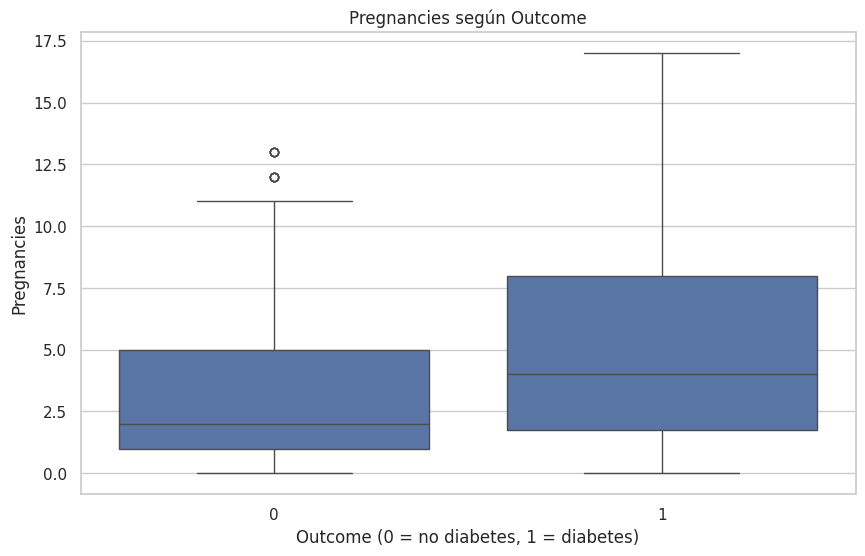

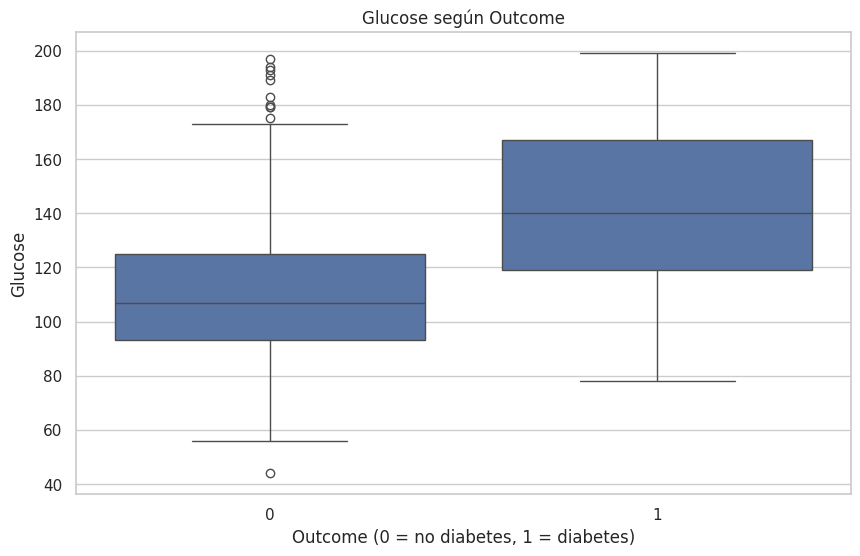

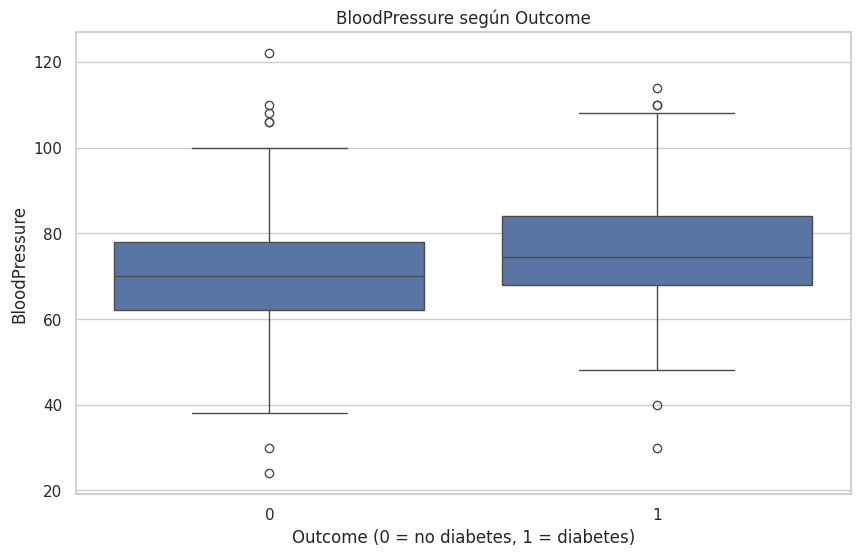

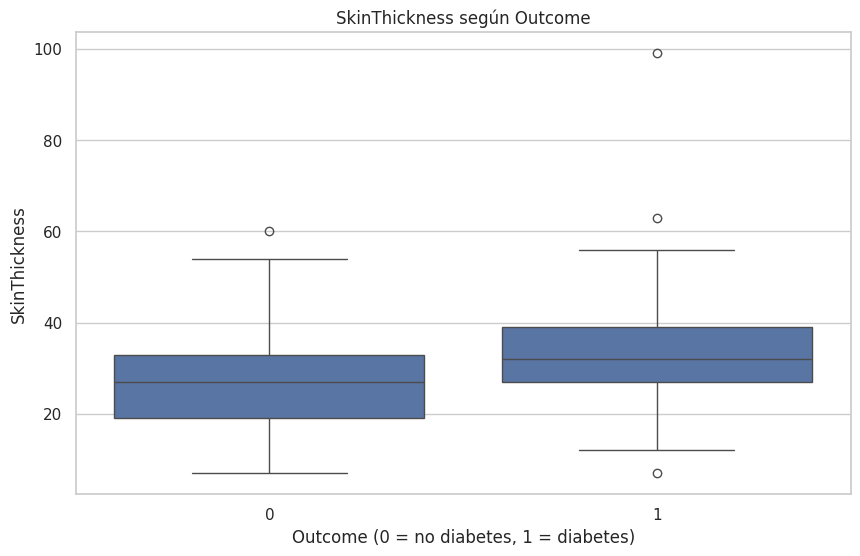

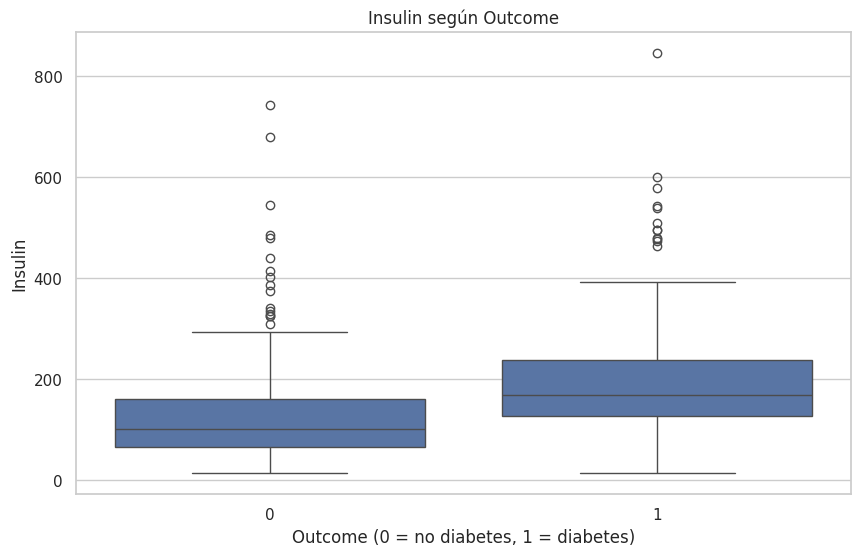

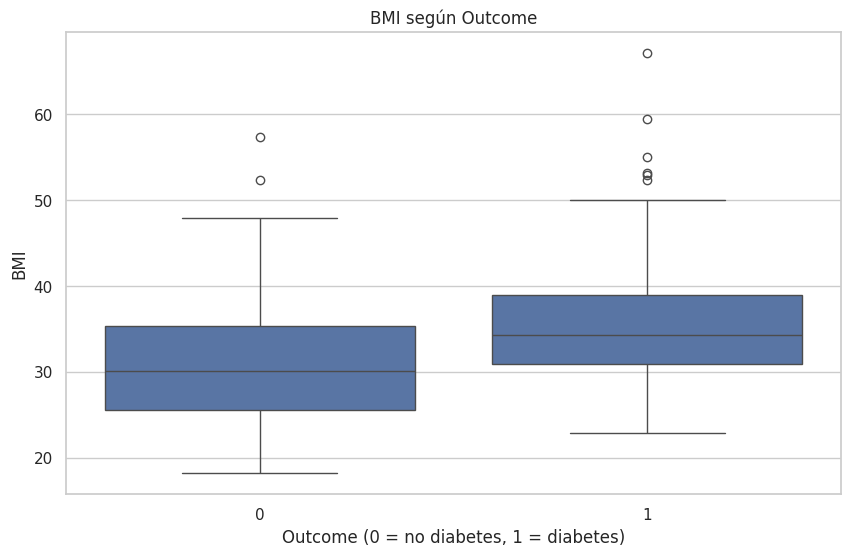

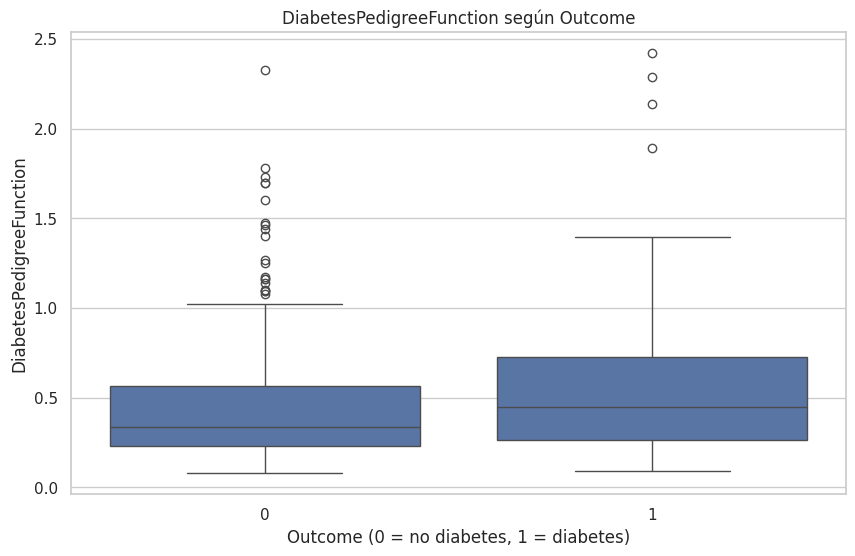

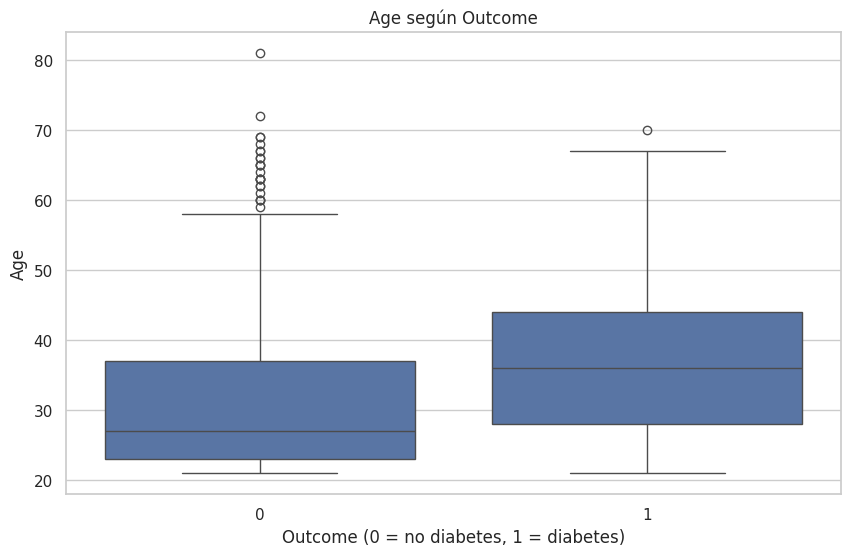

In [21]:
# ==========================================
# BLOQUE 11. BOXPLOTS POR OUTCOME
# ==========================================

for col in variables:
    plt.figure()
    sns.boxplot(data=df_clean, x="Outcome", y=col)
    plt.title(f"{col} según Outcome")
    plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
    plt.ylabel(col)
    plt.show()

Pregnancies: las personas con diabetes tienden a tener un número de embarazos mayor que las personas sin diabetes.

Glucose: las personas con diabetes presentan niveles de glucosa claramente más altos que las personas sin diabetes.

BloodPressure: la presión arterial en personas con diabetes es ligeramente mayor, aunque con bastante superposición entre grupos.

SkinThickness: las personas con diabetes muestran un grosor cutáneo algo mayor en comparación con las que no tienen diabetes.

Insulin: el grupo con diabetes tiende a presentar niveles de insulina más altos y más dispersos.

BMI: las personas con diabetes tienen un IMC más alto en términos generales que las personas sin diabetes.

DiabetesPedigreeFunction: quienes tienen diabetes muestran valores algo mayores de predisposición familiar a diabetes.

Age: las personas con diabetes tienden a ser de mayor edad que las personas sin diabetes.

###Análisis de diferencias estadísticas entre grupos

Compara, variable por variable, si las personas con diabetes y sin diabetes presentan diferencias estadísticamente relevantes en sus valores. Para hacerlo, primero separa cada variable en dos grupos: uno con Outcome = 0 (sin diabetes) y otro con Outcome = 1 (con diabetes), eliminando los valores faltantes.

Mann-Whitney U es una prueba no paramétrica usada para comparar dos grupos independientes cuando no conviene asumir normalidad en los datos, como ocurre aquí por la presencia de asimetría y outliers. Además, calcula la mediana de cada grupo y la diferencia de medianas, para saber no solo si hay diferencia, sino también en qué dirección y de qué tamaño aproximado.

In [22]:
# ==========================================
# BLOQUE 12. PRUEBAS ESTADÍSTICAS ENTRE GRUPOS
# ==========================================

resultados = []

for col in variables:
    # separar la variable por grupo, quitando NaN
    grupo_no = df_clean[df_clean["Outcome"] == 0][col].dropna()
    grupo_si = df_clean[df_clean["Outcome"] == 1][col].dropna()

    # prueba no paramétrica Mann-Whitney U
    stat, p = stats.mannwhitneyu(grupo_no, grupo_si, alternative="two-sided")

    # tamaño de efecto simple basado en diferencia de medianas
    med_no = grupo_no.median()
    med_si = grupo_si.median()
    dif_med = med_si - med_no

    resultados.append({
        "Variable": col,
        "n_no_diabetes": len(grupo_no),
        "n_diabetes": len(grupo_si),
        "Mediana_no_diabetes": med_no,
        "Mediana_diabetes": med_si,
        "Diferencia_medianas": dif_med,
        "p_value": p
    })

resultados_df = pd.DataFrame(resultados).sort_values("p_value")

print("Resultados de pruebas Mann-Whitney U:")
print(resultados_df)

Resultados de pruebas Mann-Whitney U:
                   Variable  n_no_diabetes  n_diabetes  Mediana_no_diabetes  \
1                   Glucose            497         266              107.000   
7                       Age            500         268               27.000   
5                       BMI            491         266               30.100   
4                   Insulin            264         130              102.500   
3             SkinThickness            361         180               27.000   
0               Pregnancies            500         268                2.000   
6  DiabetesPedigreeFunction            500         268                0.336   
2             BloodPressure            481         252               70.000   

   Mediana_diabetes  Diferencia_medianas       p_value  
1           140.000               33.000  1.305039e-40  
7            36.000                9.000  1.142200e-17  
5            34.300                4.200  1.818811e-17  
4           169.500   

n_no_diabetes y n_diabetes indican cuántos datos válidos se compararon en cada grupo-

Mediana_no_diabetes y Mediana_diabetes muestran el valor típico de la variable en cada grupo.

Diferencia_medianas indica cuánto aumenta o disminuye la mediana en el grupo con diabetes.

p_value muestra si esa diferencia es estadísticamente significativa.

Comparamos la mediana del grupo sin diabetes con la mediana del grupo con diabetes para cada variable, y verificamos que esa diferencia sea estadísticamente significativa con el p_value.

Como los p_value son muy pequeños, la diferencia no parece ser por azar.

Las personas con diabetes en esta muestra tienden a tener mayor glucosa, mayor insulina, mayor edad, mayor IMC, mayor número de embarazos y una predisposición familiar algo más alta


###Correlaciones entre variables y presencia de diabetes

Calculamos la matriz de correlación entre todas las variables numéricas del dataset y luego se extrae, en particular, la correlación de cada variable con Outcome.

La correlación mide la fuerza y dirección de la relación lineal entre dos variables: valores cercanos a 1 indican relación positiva fuerte, valores cercanos a -1 indican relación negativa fuerte, y valores cercanos a 0 indican poca relación lineal.

Esto se hace para identificar qué variables parecen estar más asociadas con la presencia de diabetes.

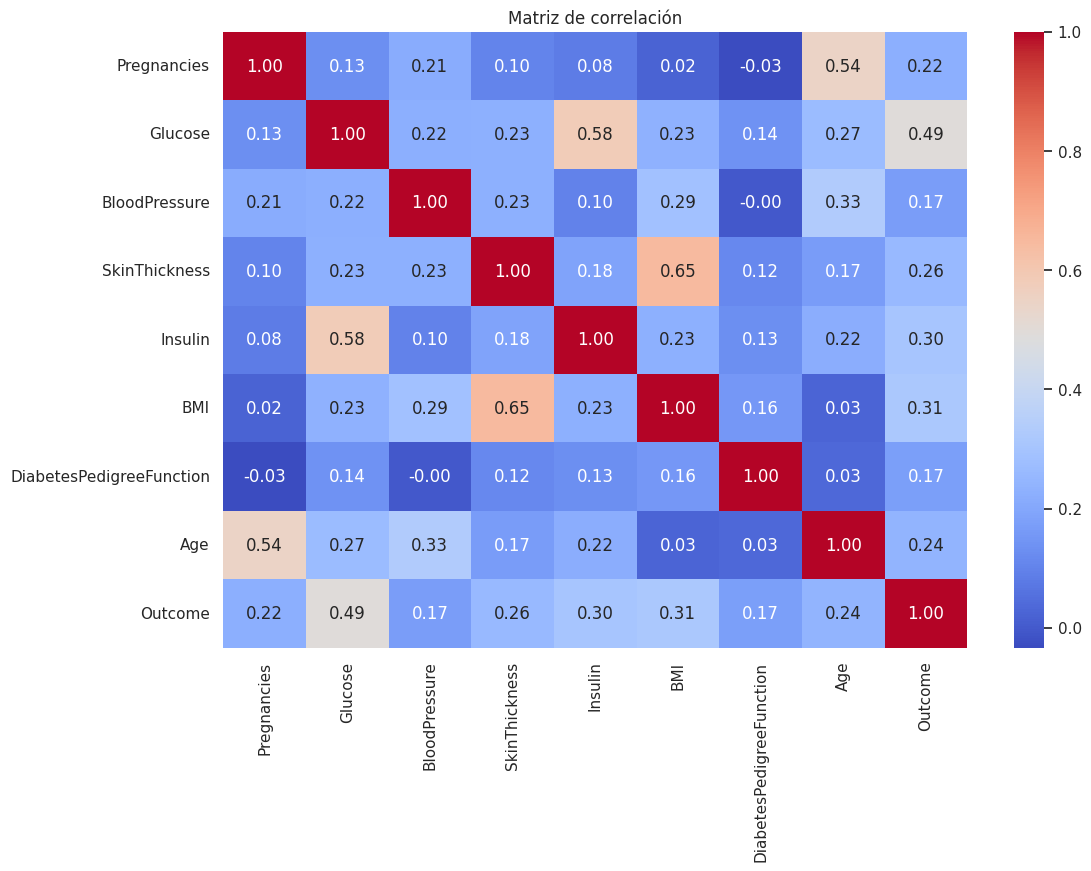

Correlación de cada variable con Outcome:
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64


In [23]:
# ==========================================
# BLOQUE 13. CORRELACIONES
# ==========================================

# calcular matriz de correlación de Pearson
corr_matrix = df_clean.corr(numeric_only=True)

# mostrar heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# ordenar correlación con Outcome
corr_outcome = corr_matrix["Outcome"].drop("Outcome").sort_values(ascending=False)

print("Correlación de cada variable con Outcome:")
print(corr_outcome)

La variable más correlacionada con Outcome es Glucose (0.49), seguida por BMI (0.31), Insulin (0.30), SkinThickness (0.26) y Age (0.24), mientras que BloodPressure y DiabetesPedigreeFunction muestran relaciones más débiles.

Por lo que, se concluye que las personas con diabetes tienden a concentrar valores más altos en glucosa, IMC, insulina, grosor cutáneo y edad.

###Probabilidad de diabetes según número de embarazos

Analizamos cómo cambia la probabilidad observada de diabetes según el número de embarazos para ver si el número de embarazos está asociado con cambios en la prevalencia de diabetes dentro de la muestra.

Tomamos las columnas Pregnancies y Outcome, luego agrupamos Pregnancies en cuatro categorías: 0, 1–2, 3–5 y 6 o más embarazos. Después calcula, para cada grupo, cuántas personas hay (n), cuántas tienen diabetes (casos_diabetes) y cuál es la proporción de diabetes dentro de ese grupo (prob_diabetes).

Probabilidad de diabetes según número de embarazos:
  grupo_embarazos    n  casos_diabetes  prob_diabetes
0               0  111              38       0.342342
1             1-2  238              48       0.201681
2             3-5  200              71       0.355000
3         6 o más  219             111       0.506849


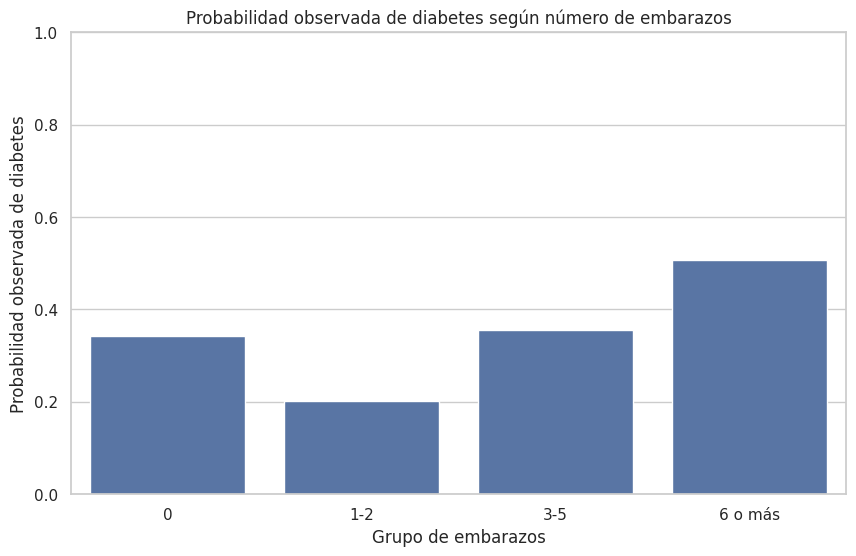

In [24]:
#Probabilidad de diabetes por categorías de embarazo
# ==========================================
# BLOQUE 15. ANÁLISIS DE PREGNANCIES
# ==========================================

# crear copia con categorías clínicas simples
temp_preg = df_clean[["Pregnancies", "Outcome"]].copy()

# categorizar número de embarazos
temp_preg["grupo_embarazos"] = pd.cut(
    temp_preg["Pregnancies"],
    bins=[-1, 0, 2, 5, 20],
    labels=["0", "1-2", "3-5", "6 o más"]
)

# calcular prevalencia por grupo
prob_preg = temp_preg.groupby("grupo_embarazos", observed=False).agg(
    n=("Outcome", "count"),
    casos_diabetes=("Outcome", "sum"),
    prob_diabetes=("Outcome", "mean")
).reset_index()

print("Probabilidad de diabetes según número de embarazos:")
print(prob_preg)

# gráfica
plt.figure()
sns.barplot(data=prob_preg, x="grupo_embarazos", y="prob_diabetes")
plt.title("Probabilidad observada de diabetes según número de embarazos")
plt.xlabel("Grupo de embarazos")
plt.ylabel("Probabilidad observada de diabetes")
plt.ylim(0, 1)
plt.show()

En el grupo de 0 embarazos hay 111 personas, de las cuales 38 tienen diabetes, por lo que la probabilidad observada es aproximadamente 0.342; en 1–2 embarazos la probabilidad baja a 0.202; en 3–5 embarazos sube a 0.355; y en 6 o más llega a 0.507, que es la más alta.

Las personas con 6 o más embarazos presentan la mayor probabilidad observada de diabetes, mientras que el grupo de 1–2 embarazos muestra la más baja.

###Comparación de probabilidad de diabetes entre niveles bajos y altos de cada variable

Comparamos para cada variable, la probabilidad observada de diabetes en dos grupos extremos: las personas con valores bajos de esa variable (menores o iguales al primer cuartil, Q1) y las personas con valores altos (mayores o iguales al tercer cuartil, Q3).

Para hacerlo, primero se toma una variable y Outcome, eliminamos faltantes, calculamos Q1 y Q3, se forma el grupo bajo y el grupo alto, y luego se calcula la proporción de personas con diabetes en cada uno, es decir, P(Diabetes | bajo) y P(Diabetes | alto).

Finalmente, se calcula la razón simple alto/bajo, que indica cuántas veces es mayor la probabilidad de diabetes en el grupo alto frente al grupo bajo.

Por ejemplo, en Glucose, Q1 = 99 y Q3 = 141, la probabilidad de diabetes en el grupo bajo es 0.0729, mientras que en el grupo alto es 0.6875, por lo que la razón es 9.43; esto significa que las personas con glucosa alta tienen una probabilidad observada de diabetes aproximadamente 9.4 veces mayor que las personas con glucosa baja.

In [25]:
# ==========================================
# BLOQUE 16. PROBABILIDAD CONDICIONADA POR CUARTILES
# ==========================================

resultados_prob = []

for col in variables:
    temp = df_clean[[col, "Outcome"]].dropna().copy()

    # calcular cuartiles
    q1 = temp[col].quantile(0.25)
    q3 = temp[col].quantile(0.75)

    # grupo bajo: <= Q1
    grupo_bajo = temp[temp[col] <= q1]

    # grupo alto: >= Q3
    grupo_alto = temp[temp[col] >= q3]

    # probabilidad empírica de diabetes en cada grupo
    p_bajo = grupo_bajo["Outcome"].mean()
    p_alto = grupo_alto["Outcome"].mean()

    # razón de probabilidades simple
    razon = p_alto / p_bajo if p_bajo != 0 else np.nan

    resultados_prob.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "P(Diabetes | bajo)": p_bajo,
        "P(Diabetes | alto)": p_alto,
        "Razon_simple_alto_vs_bajo": razon
    })

resultados_prob_df = pd.DataFrame(resultados_prob).sort_values("Razon_simple_alto_vs_bajo", ascending=False)

print("Comparación de probabilidad de diabetes entre cuartil alto y bajo:")
print(resultados_prob_df)

Comparación de probabilidad de diabetes entre cuartil alto y bajo:
                   Variable        Q1         Q3  P(Diabetes | bajo)  \
1                   Glucose  99.00000  141.00000            0.072917   
4                   Insulin  76.25000  190.00000            0.080808   
5                       BMI  27.50000   36.60000            0.113990   
7                       Age  24.00000   41.00000            0.141553   
3             SkinThickness  22.00000   36.00000            0.153333   
2             BloodPressure  64.00000   80.00000            0.228856   
6  DiabetesPedigreeFunction   0.24375    0.62625            0.255208   
0               Pregnancies   1.00000    6.00000            0.272358   

   P(Diabetes | alto)  Razon_simple_alto_vs_bajo  
1            0.687500                   9.428571  
4            0.514851                   6.371287  
5            0.487047                   4.272727  
7            0.525773                   3.714333  
3            0.468966        

Se identifican qué variables cambian más fuertemente el riesgo observado de diabetes y, por tanto, cuáles parecen ser más relevantes.

Glucose es la variable que más incrementa la probabilidad observada de diabetes, seguida por Insulin, BMI y Age, mientras que variables como BloodPressure, DiabetesPedigreeFunction y Pregnancies también muestran aumento, pero de menor magnitud.

Resumen final de las variables más importantes

In [26]:
# ==========================================
# BLOQUE 17. RESUMEN FINAL DE RELEVANCIA
# CON TABLA Y GRÁFICAS
# ==========================================

# ------------------------------------------
# 1. Preparar tabla de correlaciones
# ------------------------------------------

# corr_outcome viene del BLOQUE 13
# lo convertimos en dataframe para poder unirlo
corr_outcome_df = corr_outcome.reset_index()
corr_outcome_df.columns = ["Variable", "Correlacion_Outcome"]

# ------------------------------------------
# 2. Unir toda la evidencia en una sola tabla
# ------------------------------------------

# resultados_df viene del BLOQUE 12
# resultados_prob_df viene del BLOQUE 16

tabla_final = resultados_df.merge(
    corr_outcome_df,
    on="Variable",
    how="left"
).merge(
    resultados_prob_df[
        ["Variable", "P(Diabetes | bajo)", "P(Diabetes | alto)", "Razon_simple_alto_vs_bajo"]
    ],
    on="Variable",
    how="left"
)

# ------------------------------------------
# 3. Crear métricas auxiliares para graficar
# ------------------------------------------

# transformar el p-value para que sea más fácil de visualizar
# mientras más grande sea -log10(p), más significativa es la variable
tabla_final["Significancia_-log10_p"] = -np.log10(tabla_final["p_value"])

# valor absoluto de la correlación para medir fuerza sin importar signo
tabla_final["Abs_Correlacion"] = tabla_final["Correlacion_Outcome"].abs()

# magnitud absoluta de la diferencia de medianas
tabla_final["Abs_Diferencia_Medianas"] = tabla_final["Diferencia_medianas"].abs()

# ------------------------------------------
# 4. Ordenar tabla final
# ------------------------------------------

# ordenamos por significancia estadística y luego por razón de probabilidad
tabla_final = tabla_final.sort_values(
    by=["p_value", "Razon_simple_alto_vs_bajo"],
    ascending=[True, False]
).reset_index(drop=True)

# mostrar tabla final
print("Tabla final de evidencia estadística y probabilística:")
print(tabla_final)


Tabla final de evidencia estadística y probabilística:
                   Variable  n_no_diabetes  n_diabetes  Mediana_no_diabetes  \
0                   Glucose            497         266              107.000   
1                       Age            500         268               27.000   
2                       BMI            491         266               30.100   
3                   Insulin            264         130              102.500   
4             SkinThickness            361         180               27.000   
5               Pregnancies            500         268                2.000   
6  DiabetesPedigreeFunction            500         268                0.336   
7             BloodPressure            481         252               70.000   

   Mediana_diabetes  Diferencia_medianas       p_value  Correlacion_Outcome  \
0           140.000               33.000  1.305039e-40             0.494650   
1            36.000                9.000  1.142200e-17             0.238356

###Qué variables están más aociadas con la diabetes en general

Se presenta la correlación de cada variable con Outcome (presencia o ausencia de diabetes)

La correlación indica qué tan relacionada está una variable con la diabetes en términos lineales: mientras más alto sea el valor positivo, mayor es la asociación positiva, lo que significa que al aumentar esa variable también tiende a aumentar la presencia de diabetes en la muestra.

Glucose aparece como la variable con mayor correlación, seguida por BMI, Insulin, SkinThickness y Age, mientras que BloodPressure y DiabetesPedigreeFunction muestran relaciones más débiles.

la glucosa es la variable más vinculada con la diabetes en este dataset, y que otras variables como IMC, insulina, grosor cutáneo y edad también tienen un papel importante, aunque menor.


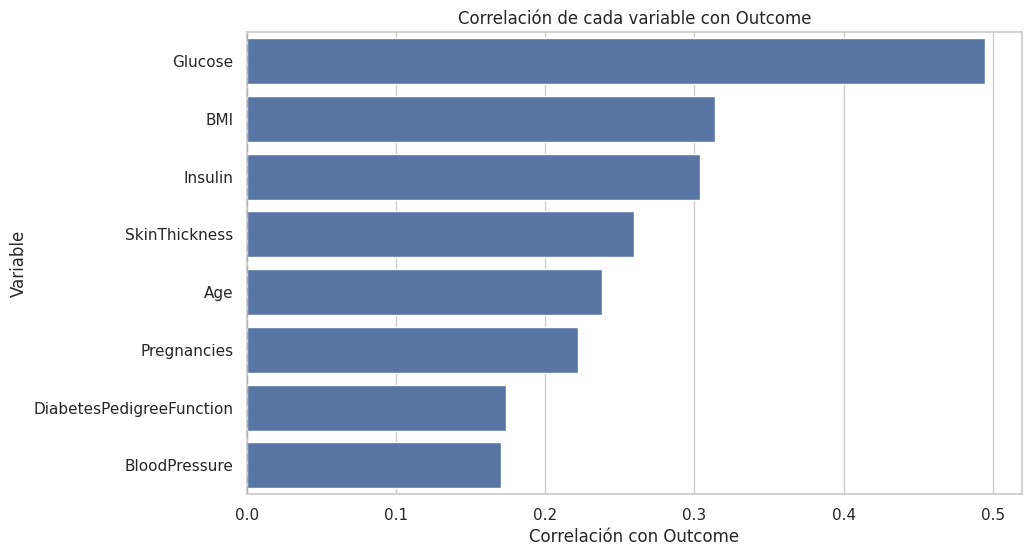

In [27]:
# ------------------------------------------
# 5. GRÁFICA 1:
# Correlación con Outcome
# ------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tabla_final.sort_values("Correlacion_Outcome", ascending=False),
    x="Correlacion_Outcome",
    y="Variable"
)
plt.title("Correlación de cada variable con Outcome")
plt.xlabel("Correlación con Outcome")
plt.ylabel("Variable")
plt.axvline(0, color="black", linestyle="--")
plt.show()

Perfil típico de personas con y sin diabetes

In [30]:
# ==========================================
# BLOQUE 18. PERFIL OBSERVADO DE MAYOR RIESGO
# ==========================================

# calcular medianas por grupo Outcome
perfil = df_clean.groupby("Outcome")[variables].median().T
perfil.columns = ["Mediana_no_diabetes", "Mediana_diabetes"]

print("Perfil típico según medianas por grupo:")
print(perfil)

Perfil típico según medianas por grupo:
                          Mediana_no_diabetes  Mediana_diabetes
Pregnancies                             2.000             4.000
Glucose                               107.000           140.000
BloodPressure                          70.000            74.500
SkinThickness                          27.000            32.000
Insulin                               102.500           169.500
BMI                                    30.100            34.300
DiabetesPedigreeFunction                0.336             0.449
Age                                    27.000            36.000


###Qué variables aumentan más la probabilidad de diabetes


Impacto relativo de cada variable en la probabilidad observada de diabetes.

Comparamos la probabilidad de diabetes en personas con valores altos de una variable frente a personas con valores bajos de la misma variable; por eso, mientras más grande sea la barra, mayor es el cambio de probabilidad entre ambos extremos.

Es se hace para identificar qué variables cambian más fuertemente el riesgo observado de diabetes y, por tanto, cuáles son más relevantes desde un enfoque probabilístico.

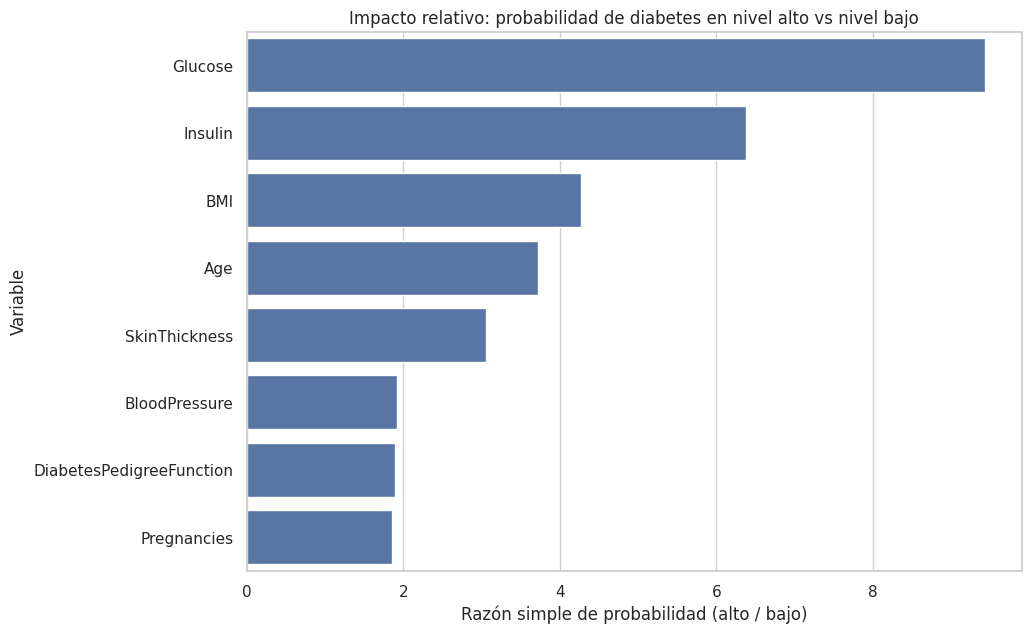

In [31]:
# ==========================================
# BLOQUE 19. GRÁFICA RESUMEN DE IMPACTO
# ==========================================

# ordenar de mayor a menor razón
plot_df = resultados_prob_df.sort_values("Razon_simple_alto_vs_bajo", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=plot_df, x="Razon_simple_alto_vs_bajo", y="Variable")
plt.title("Impacto relativo: probabilidad de diabetes en nivel alto vs nivel bajo")
plt.xlabel("Razón simple de probabilidad (alto / bajo)")
plt.ylabel("Variable")
plt.show()

A comparación de la anterior gráfica, esta gráfica ordena las variables según cuánto cambia la probabilidad de diabetes al comparar el grupo alto contra el grupo bajo. No se trata de qué tan asociada está cada variable con la diabetes en todo el rango de valores.

Glucose aparece como la variable con mayor impacto, seguida por Insulin, BMI y Age, lo que indica que las personas con valores altos en esas variables tienen una probabilidad de diabetes mucho mayor que las personas con valores bajos.

A partir de todo el análisis estadístico y probabilístico realizado, se concluye que las variables que más se relacionan con la presencia de diabetes en este dataset son Glucose, Insulin, BMI y Age, siendo Glucose la más importante de todas. Esto se observa porque no solo presenta la mayor asociación con Outcome, sino también el mayor aumento en la probabilidad observada de diabetes cuando se comparan personas con valores bajos frente a personas con valores altos.

Además, las personas con diabetes tienden a mostrar medianas más elevadas en estas variables, así como en Pregnancies y DiabetesPedigreeFunction, lo que indica que, dentro de esta muestra, el perfil más asociado con diabetes corresponde a personas con mayor glucosa, mayor insulina, mayor IMC, mayor edad, más embarazos y una predisposición familiar algo más alta.